<a href="https://colab.research.google.com/github/KhytsenkoIgor/python-data-analysis-tasks/blob/main/HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [54]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')

In [55]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [56]:
df.head(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [57]:
df.tail(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,2012-12-19,19,51,2,Wednesday,2012,12,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,2012-12-19,19,51,2,Wednesday,2012,12,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,2012-12-19,19,51,2,Wednesday,2012,12,21
2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,2012-12-19,19,51,2,Wednesday,2012,12,22
2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,2012-12-19,19,51,2,Wednesday,2012,12,23


In [58]:
df.shape

(10886, 19)

In [59]:
df.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'date', 'day',
       'week', 'weekday_num', 'weekday', 'year', 'month', 'hour'],
      dtype='object')

**Відповідь:**

1.  Набір даних містить 10 886 рядків і 19 колонок.
2.  Один рядок набору даних містить інформацію за одну годину,рівень деталізації даних погодинний.Весь набір охоплює період від 01.01.2011 00:00 до 19.12.2012 23:00.



## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [60]:
daily_rentals = df.groupby('date')[['count']].sum()   # Групуємо дані про кількість орендованих велосипедів поденно.

daily_rentals.head()

,count
date,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600


<Axes: title={'center': 'Динаміка оренди велосипедів'}, xlabel='date'>

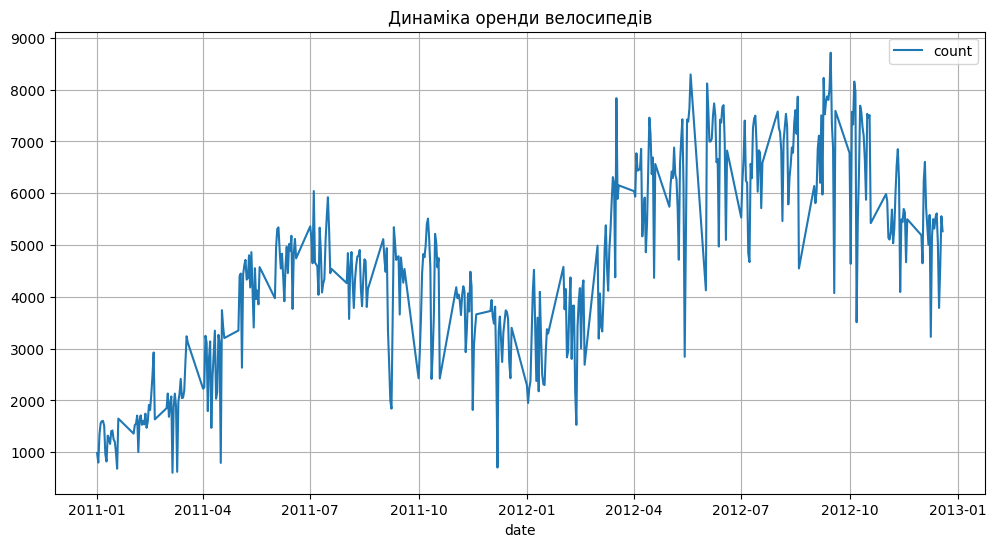

In [61]:
daily_rentals.plot(
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    grid=True
)

In [62]:
daily_rentals = df.groupby('date')[['count']].sum()

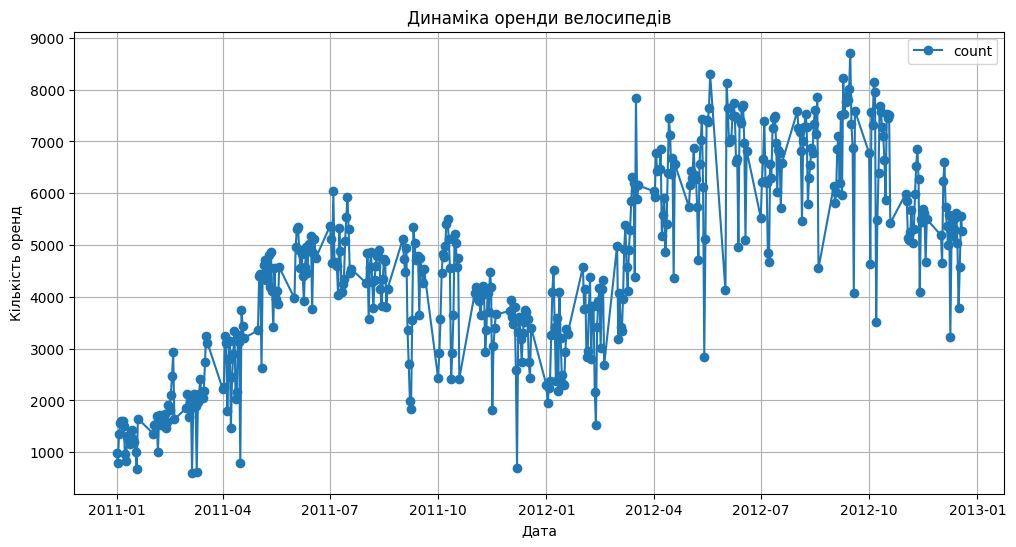

In [63]:
daily_rentals.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів',
    xlabel='Дата',
    ylabel='Кількість оренд',
    grid=True
);

In [112]:
# Створюємо функцію india_season, яка за номером місяця визначає сезон в Індії:
# 12, 1, 2  Winter; 3, 4, 5  Summer; 6, 7, 8, 9  Monsoon; 10, 11 Post-Monsoon.

def india_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Post-Monsoon'

In [116]:
# Створюємо нову колонку weather_season_india та за допомогою apply(), визначаємо сезон для кожного значення колонки month.

df['weather_season_india'] = df['month'].apply(india_season)

In [117]:
# Виводимо перші 5 рядків колонок month і weather_season_india для перевірки результату.
df[['month', 'weather_season_india']].head()

,month,weather_season_india
datetime,,
2011-01-01 00:00:00,1,Winter
2011-01-01 01:00:00,1,Winter
2011-01-01 02:00:00,1,Winter
2011-01-01 03:00:00,1,Winter
2011-01-01 04:00:00,1,Winter


In [120]:
# Створюємо зведену таблицю season_daily: сумарна кількість оренд велосипедів за кожен день.

season_daily = pd.pivot_table(
    df,
    index='date',
    columns='weather_season_india',
    values='count',
    aggfunc='sum'
)

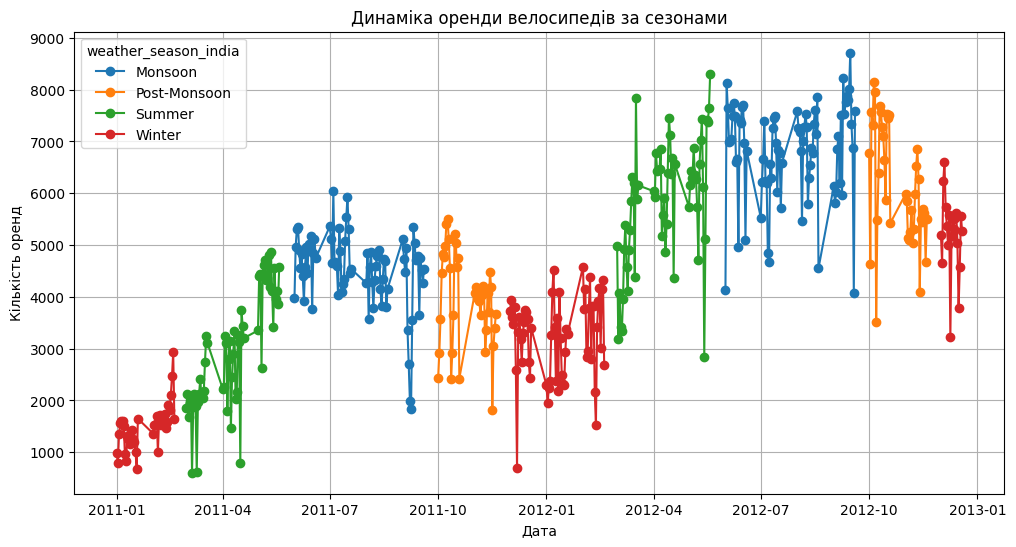

In [122]:
# Будуємо лінійний графік, щоб побачити динаміку кількості оренд велосипедів за датами та порівняти її між різними сезонами.

season_daily.plot(
    kind='line',
    marker='o',
    figsize=(12, 6),
    title='Динаміка оренди велосипедів за сезонами',
    xlabel='Дата',
    ylabel='Кількість оренд',
    grid=True
);



In [132]:
# Групуємо дані за сезонами та розраховуємо середню кількість оренд велосипедів за годину для кожного сезону.

season_rentals = df.groupby('weather_season_india')[['count']].mean()

season_rentals

,count
weather_season_india,
Monsoon,236.322359
Post-Monsoon,210.688255
Summer,184.074210
Winter,125.753430


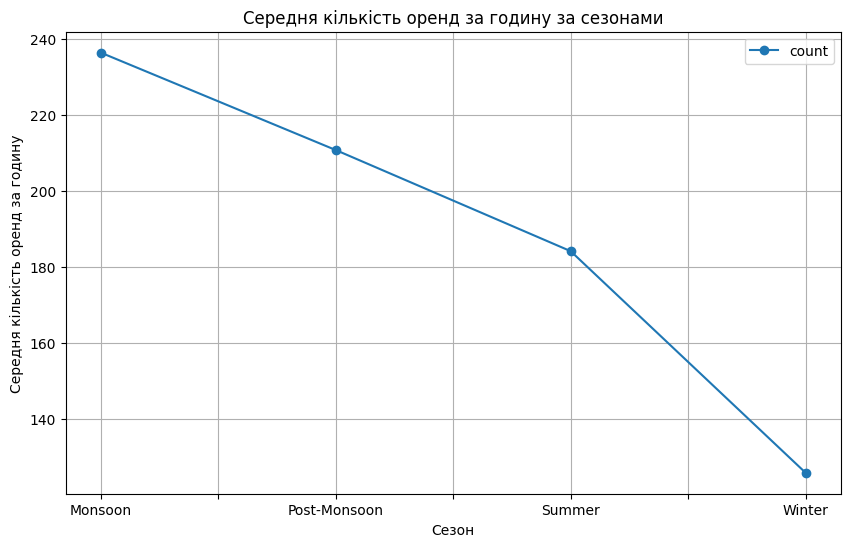

In [133]:
# Будуємо лінійний графік, щоб наочно порівняти середню кількість оренд за годину велосипедів у різні сезони.

season_rentals.plot(
    kind='line',
    marker='o',
    figsize=(10, 6),
    title='Середня кількість оренд за годину за сезонами',
    xlabel='Сезон',
    ylabel='Середня кількість оренд за годину',
    grid=True
);

In [71]:
# Групуємо дані за датою та сезоном і розраховуємо загальну кількість оренд велосипедів за кожен день.

daily_rentals = df.groupby(['date', 'weather_season_india'])[['count']].sum()

daily_rentals.head()

,,count
date,weather_season_india,
2011-01-01,Winter,985
2011-01-02,Winter,801
2011-01-03,Winter,1349
2011-01-04,Winter,1562
2011-01-05,Winter,1600


In [126]:
# Для кожного сезону розраховуємо середню, мінімальну та максимальну кількість оренд велосипедів за день.

season_stats = daily_rentals.groupby('weather_season_india')['count'].agg(
    ['mean', 'min', 'max']
)

season_stats

,mean,min,max
weather_season_india,,,
Monsoon,5667.072368,1842,8714
Post-Monsoon,5050.973684,1817,8156
Summer,4395.175439,605,8294
Winter,2975.061404,683,6606


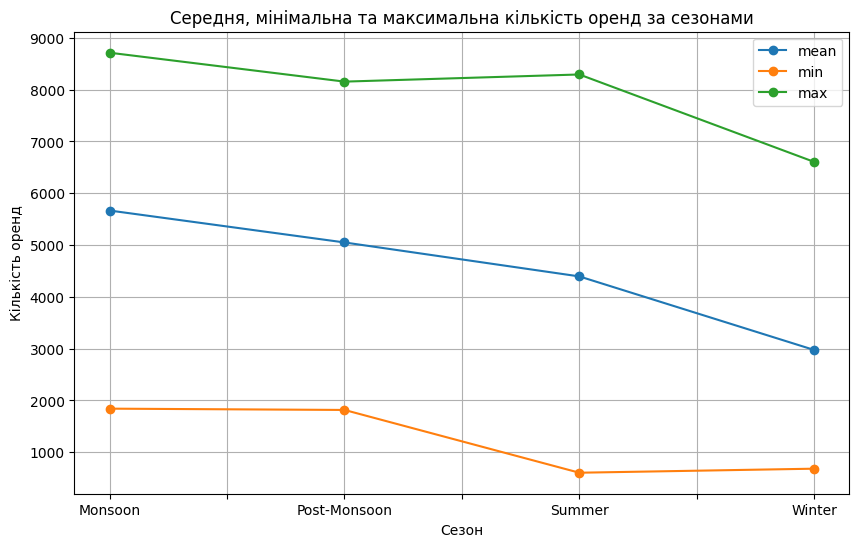

In [128]:
# Будуємо лінійний графік для порівняння середньої, мінімальної та максимальної кількості оренд велосипедів у кожному сезоні.

season_stats.plot(
    kind='line',
    marker='o',
    figsize=(10, 6),
    title='Середня, мінімальна та максимальна кількість оренд за сезонами',
    xlabel='Сезон',
    ylabel='Кількість оренд',
    grid=True
);

In [131]:
# Групуємо дані за сезонами та розраховуємо середні значення погодних показників: температури, відчутної температури, вологості,
# швидкості вітру та показника weather.

season_weather = df.groupby('weather_season_india')[
    ['weather', 'temp', 'atemp', 'humidity', 'windspeed']
].mean()

season_weather

,weather,temp,atemp,humidity,windspeed
weather_season_india,,,,,
Monsoon,1.352263,28.357602,32.152455,62.781619,11.719052
Post-Monsoon,1.443469,18.059802,21.532868,65.067508,12.176522
Summer,1.458119,19.111543,22.666898,60.172300,14.407636
Winter,1.450871,11.843938,14.601915,60.257694,13.057125


**Відповіді на питання :**

1.   *Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?*
*   Графік має багато різких змін, тому що дані відображають кількість оренд за кожен окремий день, а попит може суттєво змінюватися залежно від погоди, дня тижня, температури та інших факторів.

2.  *Які загальні тенденції ви бачите на графіку?*


*   На графіку видно загальне зростання кількості оренд. У 2012 році рівень оренди велосипедів помітно вищий, ніж у 2011 році. Також протягом року кількість оренд поступово збільшується від зимового періоду до сезону мусонів, після чого дещо знижується.


3.   *Чи помітні якісь сезонні коливання?*


*   Сезонність досить добре помітна, середня денна кількість оренд відрізняється залежно від сезону:

Winter - 2975,
Summer - 4395,
Monsoon - 5667,
Post-Monsoon - 5051.

Найнижча середня кількість оренд спостерігається взимку, а найвища — в сезон мусонів. При цьому середня температура також змінюється, від 11,84 °C взимку до 28,36 °C у сезон мусонів. Це може бути одним із факторів, які впливають на кількість оренд.



4.   *Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?*



*  Так, на графіку є різкі піки та падіння. Мінімальна денна кількість оренд становить 605 у сезон Summer, а максимальна  8714 у сезон Monsoon. Такі відхилення можуть бути пов'язані з погодними умовами, температурою, вологістю, швидкістю вітру, вихідними або святковими днями. Для точного визначення причини конкретної аномалії потрібно окремо дослідити дані за відповідний день.










## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [77]:
# Розраховуємо середню кількість оренд за кварталами
quarter_rentals = df.groupby('season')[['count']].mean().round(2)

quarter_rentals

,count
season,
1,116.34
2,215.25
3,234.42
4,198.99


In [137]:
# Замінюємо номери кварталів на зрозумілі назви
quarter_rentals.index = ['I квартал',
                         'II квартал',
                         'III квартал',
                         'IV квартал']

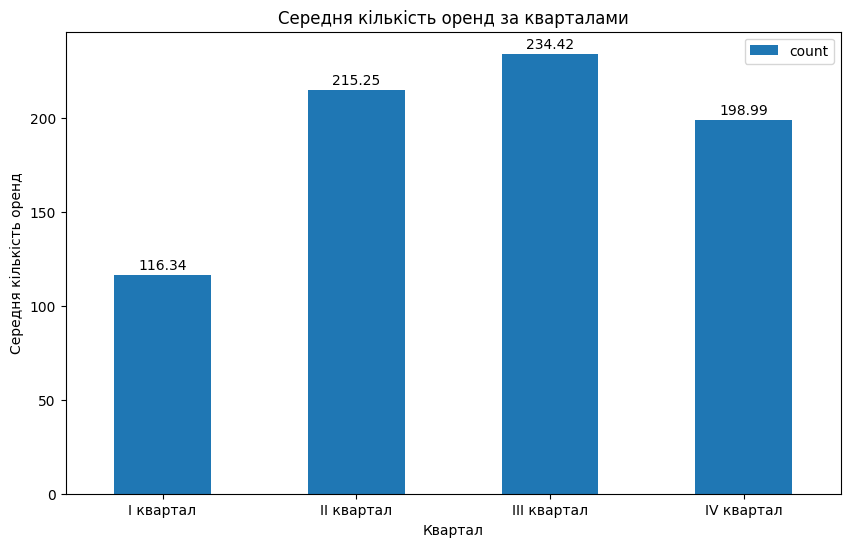

In [138]:
# Будуємо стовпчасту діаграму через Pandas
ax = quarter_rentals.plot.bar(
    figsize=(10, 6),
    title='Середня кількість оренд за кварталами',
    xlabel='Квартал',
    ylabel='Середня кількість оренд',
    grid=False,
    rot=0)

# Додаємо значення над кожним стовпцем
for i, value in enumerate(quarter_rentals['count']):
    ax.annotate(
        f'{value:.2f}',
        xy=(i, value + 3),
        ha='center');


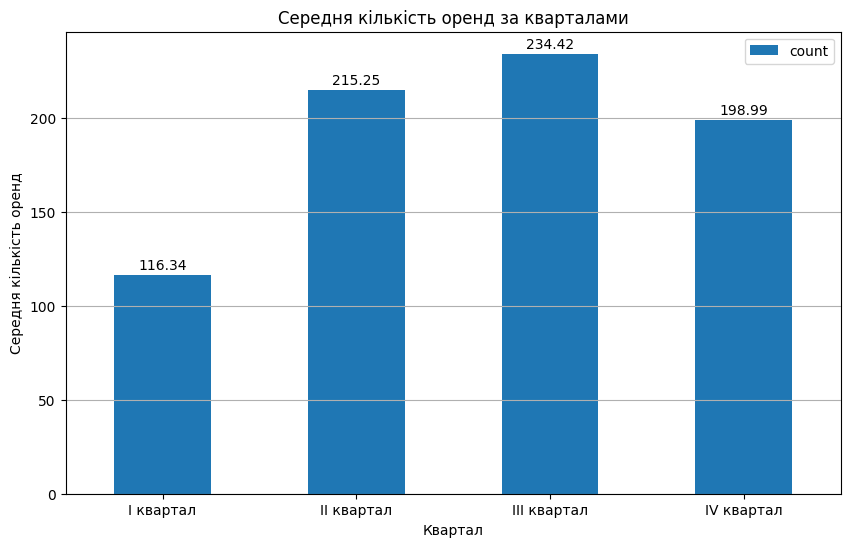

In [136]:
ax = quarter_rentals.plot.bar(
    figsize=(10, 6),
    title='Середня кількість оренд за кварталами',
    xlabel='Квартал',
    ylabel='Середня кількість оренд',
    grid=False)

labels = ['I квартал', 'II квартал', 'III квартал', 'IV квартал']
ax.set_xticklabels(labels, rotation=0)

ax.grid(axis='y')

for i, value in enumerate(quarter_rentals['count']):
    ax.annotate(
        f'{value:.2f}',
        xy=(i, value + 3),
        ha='center');

In [141]:
# Вибираємо I та III квартали для порівняння та створюємо окрему копію даних.
quarter_compare = quarter_rentals.iloc[[0, 2]].copy()

# Перейменовуємо колонку count у mean.
quarter_compare.columns = ['mean']

# Розраховуємо різницю між середньою кількістю оренд
# та меншим значенням серед двох кварталів.
quarter_compare['difference'] = (
    quarter_compare['mean'] - quarter_compare['mean'].min()
)

# Розраховуємо різницю у відсотках відносно меншого значення.
quarter_compare['difference_percent'] = (
    quarter_compare['difference'] / quarter_compare['mean'].min() * 100
)

# Розраховуємо, у скільки разів середня кількість оренд
# більша за менше значення.
quarter_compare['times'] = (
    quarter_compare['mean'] / quarter_compare['mean'].min()
)

# Округлюємо результат до 2 знаків після коми.
quarter_compare.round(2)

,mean,difference,difference_percent,times
I квартал,116.34,0.00,0.0,1.00
III квартал,234.42,118.08,101.5,2.01


**Відповіді на питання :**

1.   *В який квартал найбільша середня кількість оренди велосипедів?*
*   Найбільша середня кількість оренд велосипедів у III кварталі — приблизно 234,42 оренди.

2.  *Як ви можете пояснити таку сезонну закономірність?*


*   У III кварталі спостерігається найбільша середня кількість оренд — 234,4 велосипеда за годину. У цей же період середня температура є найвищою серед усіх кварталів — близько 28,8 °C, середня вологість становить 64,1%, а швидкість вітру — 11,5, що є одним із найнижчих показників серед кварталів. Такі погодні умови могли бути сприятливими для використання велосипедів і, відповідно, бути одним із факторів високого попиту.

Для порівняння, у I кварталі середня кількість оренд найнижча — 116,3 велосипеда за годину. Середня температура в цей період становить лише близько 12,5 °C, а середня швидкість вітру є вищою — близько 14,6. Таким чином, у холодніший період із сильнішим вітром велосипеди орендують значно рідше.

Отже, за отриманими даними простежується зв'язок між погодними умовами та кількістю оренд: зі зростанням температури та зменшенням швидкості вітру попит на велосипеди в цілому зростає. Водночас ці дані показують саме зв'язок між показниками, тому не можна стверджувати, що погода є єдиною причиною зміни кількості оренд.


3.   *У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталами?*


* У III кварталі середня кількість оренд становить 234,42 велосипеда за годину, тоді як у I кварталі — 116,34 велосипеда за годину. Абсолютна різниця між ними складає 118,08 оренди за годину. Отже, у III кварталі середня кількість оренд на 101,5% вища, або приблизно у 2,01 раза більша, ніж у I кварталі.





## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [81]:
monthly_rentals = df.groupby('month')[['count']].mean().round(2)  # Розраховуємо середню кількість оренд для кожного місяця

monthly_rentals

,count
month,
1,90.37
2,110.00
3,148.17
4,184.16
5,219.46
6,242.03
7,235.33
8,234.12
9,233.81


In [82]:
# Встановлюємо порядок місяців від 1 до 12
# Це потрібно, щоб графік відображав календарний рік у правильній послідовності
monthly_rentals = monthly_rentals.loc[
    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
]

# Перетворюємо індекс місяців у текстовий формат
# Це потрібно для коректного відображення назв місяців на осі X
monthly_rentals.index = [
    '1', '2', '3', '4', '5', '6',
    '7', '8', '9', '10', '11', '12'
]

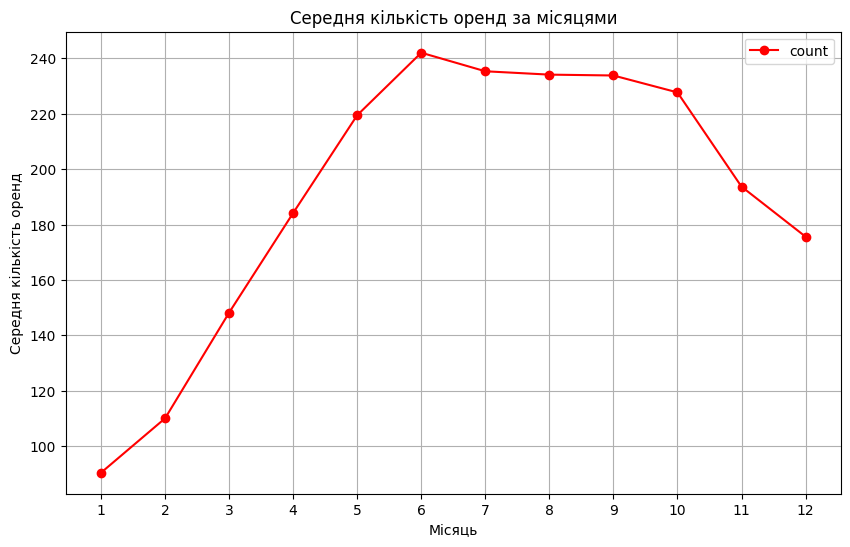

In [83]:
# Будуємо лінійний графік середньої кількості оренд за місяцями

monthly_rentals.plot.line(
    marker='o',                   # Додаємо маркери-точки для кожного місяця
    color='red',                  # Встановлюємо червоний колір лінії
    figsize=(10, 6),              # Встановлюємо розмір графіка
    title='Середня кількість оренд за місяцями',    # Заголовок графіка
    xlabel='Місяць',              # Назва осі X
    ylabel='Середня кількість оренд',    # Назва осі Y
    grid=True,                    # Додаємо сітку для зручності читання
    xticks=range(12)              # Відображаємо всі 12 місяців на осі X
);

In [84]:
# Створюємо нову змінну та розраховуємо середню кількість оренд
monthly_rentals_12_11 = df.groupby('month')[['count']].mean().round(2)

In [85]:
# Змінюємо порядок місяців, щоб графік починався з грудня
# Це потрібно для наочнішого відображення сезонів Індії: Winter = 12, 1, 2
monthly_rentals_12_11 = monthly_rentals_12_11.loc[
    [12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
]

In [86]:
# Перетворюємо індекс місяців у текстовий формат
# Це потрібно для коректного відображення місяців на осі X
monthly_rentals_12_11.index = [
    '12', '1', '2', '3', '4', '5',
    '6', '7', '8', '9', '10', '11'
]

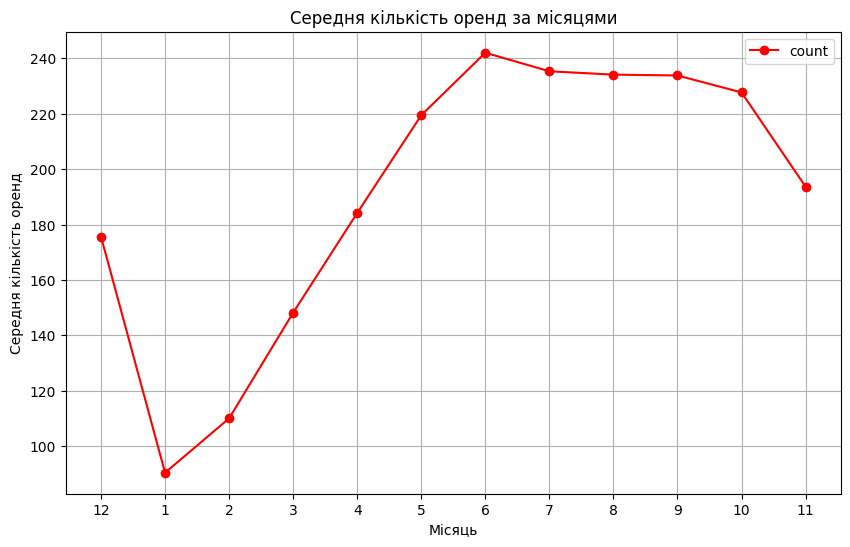

In [87]:
# Будуємо лінійний графік середньої кількості оренд за місяцями
monthly_rentals_12_11.plot.line(
    marker='o',            # Позначаємо кожен місяць точкою
    color='red',           # Встановлюємо червоний колір лінії
    figsize=(10, 6),       # Розмір графіка
    title='Середня кількість оренд за місяцями',
    xlabel='Місяць',
    ylabel='Середня кількість оренд',
    grid=True,             # Додаємо сітку для зручності читання
    xticks=range(12)       # Відображаємо всі 12 місяців на осі X
);

In [93]:
def india_season(month):         # Створюємо функцію, яка визначає сезон Індії за номером місяця
    if month in [12, 1, 2]:      # Якщо місяць : 12 або 1 або 2 то буде сезон Winter
        return 'Winter'
    elif month in [3, 4, 5]:     # Якщо місяць : 3 або 4 або 5 то  сезон Summer
        return 'Summer'
    elif month in [6, 7, 8, 9]:  # Якщо місяць : 6 або 7 або 8 або 9 то  сезон Monsoon
        return 'Monsoon'
    else:
        return 'Post-Monsoon'    # Всі інші місяці відносимо до сезону Post-Monsoon

In [94]:
# Створюємо нову колонку з назвою сезону
# До кожного значення колонки month застосовуємо функцію india_season
df['weather_season_india'] = df['month'].apply(india_season)

In [95]:
# Перевіряємо, чи правильно місяцям присвоєно назви сезонів
df[['month', 'weather_season_india']].head()

,month,weather_season_india
datetime,,
2011-01-01 00:00:00,1,Winter
2011-01-01 01:00:00,1,Winter
2011-01-01 02:00:00,1,Winter
2011-01-01 03:00:00,1,Winter
2011-01-01 04:00:00,1,Winter


In [96]:
# Перевіряємо унікальні значення в колонці weather_season_india
# Це потрібно, щоб переконатися, що всі 4 сезони присутні
df['weather_season_india'].unique()

array(['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'], dtype=object)

In [97]:
# Створюємо таблицю для сезонів на основі вже розрахованих даних
monthly_seasons = pd.DataFrame(index=monthly_rentals_12_11.index)

# Розподіляємо середню кількість оренд по окремих колонках сезонів
# Це потрібно, щоб кожен сезон відображався на графіку окремим кольором

monthly_seasons.loc[['12', '1', '2'], 'Winter'] = \
    monthly_rentals_12_11.loc[['12', '1', '2'], 'count']

monthly_seasons.loc[['3', '4', '5'], 'Summer'] = \
    monthly_rentals_12_11.loc[['3', '4', '5'], 'count']

monthly_seasons.loc[['6', '7', '8', '9'], 'Monsoon'] = \
    monthly_rentals_12_11.loc[['6', '7', '8', '9'], 'count']

monthly_seasons.loc[['10', '11'], 'Post-Monsoon'] = \
    monthly_rentals_12_11.loc[['10', '11'], 'count']

In [98]:
# Виводимо таблицю з середньою кількістю оренд по сезонах
monthly_seasons

,Winter,Summer,Monsoon,Post-Monsoon
12,175.61,NaN,NaN,NaN
1,90.37,NaN,NaN,NaN
2,110.00,NaN,NaN,NaN
3,NaN,148.17,NaN,NaN
4,NaN,184.16,NaN,NaN
5,NaN,219.46,NaN,NaN
6,NaN,NaN,242.03,NaN
7,NaN,NaN,235.33,NaN
8,NaN,NaN,234.12,NaN
9,NaN,NaN,233.81,NaN


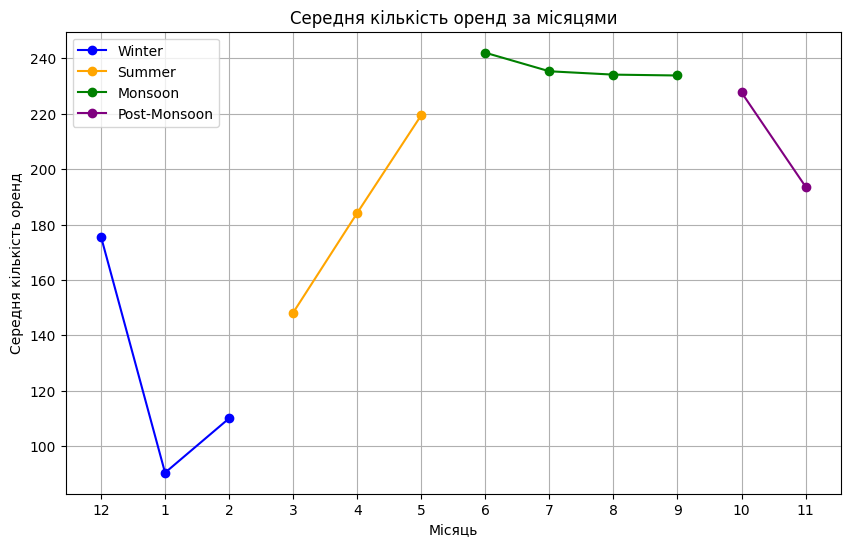

In [99]:
# Будуємо лінійний графік середньої кількості оренд за місяцями
# Кожен сезон відображаємо окремим кольором
monthly_seasons.plot.line(
    marker='o',                                # Позначаємо кожен місяць точкою
    color=['blue', 'orange', 'green', 'purple'],  # Задаємо окремий колір для кожного сезону
    figsize=(10, 6),                           # Встановлюємо розмір графіка
    title='Середня кількість оренд за місяцями',  # Заголовок графіка
    xlabel='Місяць',                           # Назва осі X
    ylabel='Середня кількість оренд',          # Назва осі Y
    grid=True,                                 # Додаємо сітку для зручності читання
    xticks=range(12)                           # Відображаємо всі 12 місяців на осі X
);

**Відповіді на питання :**

1.   *В які місяці спостерігається пік та спад оренди?*

* За графіком видно чітке зростання середньої кількості оренд від початку року до літа, від 90,37 у січні до максимального значення 242,03 у червні. У липні -вересні попит залишається стабільно високим  близько 234 - 235 оренд за годину. Починаючи з жовтня спостерігається поступове зниження, і в грудні середня кількість оренд становить 175,61. Основний період зростання припадає на січень - червень, пік на червень з жовтня починається помітний спад.

2.  *Чи збігається ця закономірність з результатами з попереднього завдання?*


*   Так ц закономірність добре узгоджується з результатами попереднього аналізу за кварталами. У I кварталі середня кількість оренд була найнижчою 116,34, що підтверджується низькими показниками січня та лютого  90,37 та 110,0. У II кварталі кількість оренд активно зростає від 184,16 у квітні до 242,03 у червні, а в III кварталі залишається стабільно високою 235,33 у липні, 234,12 у серпні та 233,81 у вересні тому саме III квартал має найбільше середнє значення  234,42. У IV кварталі спостерігається поступове зниження від 227,70 у жовтні до 175,61 у грудні, що відповідає нижчому середньому значенню кварталу  198,99. Таким чином, місячний графік підтверджує результати квартального аналізу та детальніше показує, як змінюється попит протягом року.


3.   *Як може вплинути клімат на оренду велосипедів протягом року?*


* Отримані погодні показники дозволяють припустити що одним із важливих факторів, які впливають на оренду велосипедів є температура. У холодний період Winter середня температура становить близько 11,84 °C а середня кількість оренд  приблизно 125,75 за годину. Натомість у сезон Monsoon, коли середня температура підвищується до 28,36 °C, середня кількість оренд зростає до 236,32 за годину. Водночас середня швидкість вітру в Monsoon становить близько 11,72, що нижче, ніж у Summer  14,41 та взимку  13,06, тому менша швидкість вітру разом із вищою температурою може створювати більш сприятливі умови для поїздок на велосипеді. Вологість між сезонами відрізняється не так суттєво, тому її вплив на зміну попиту за нашими даними є менш очевидним. Таким чином, можна припустити, що тепліша погода та менша швидкість вітру сприяють збільшенню кількості оренд тоді як у холодні місяці попит суттєво нижчий, але клімат є лише одним із можливих факторів, тому не можна стверджувати, що саме погода є єдиною причиною зміни попиту.


## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

In [100]:
# Рахуємо кількість записів для кожної категорії погодних умов
weather_counts = df['weather'].value_counts().sort_index()

weather_counts

,count
weather,
1,7192
2,2834
3,859
4,1


In [101]:
# Замінюємо числові коди погоди на назви для зручного відображення
weather_counts.index = [
    'Ясно',
    'Туман',
    'Легкий дощ',
    'Сильний дощ'
]

weather_counts

,count
Ясно,7192
Туман,2834
Легкий дощ,859
Сильний дощ,1


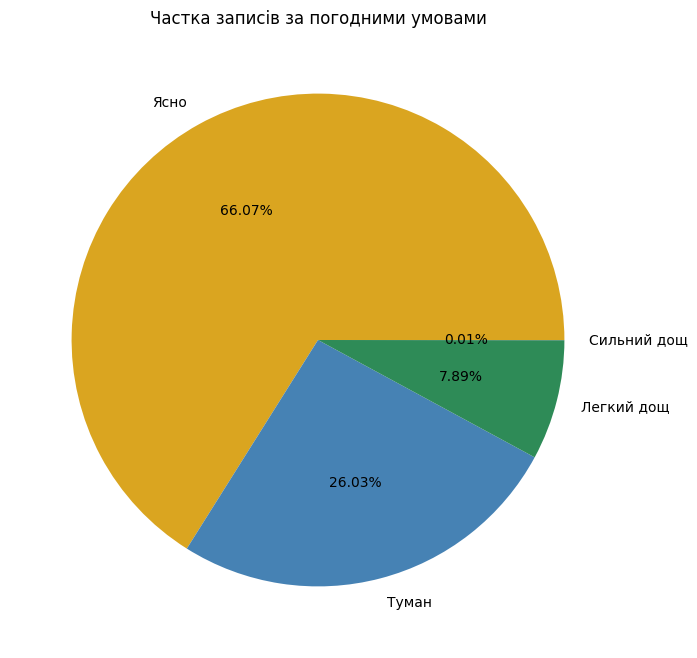

In [102]:
# Будуємо кругову діаграму розподілу погодних умов
weather_counts.plot.pie(
    autopct='%1.2f%%',                                  # Показуємо частку у відсотках
    colors=['goldenrod', 'steelblue', 'seagreen', 'plum'], # Задаємо власні кольори
    figsize=(8, 8),                                     # Розмір графіка
    title='Частка записів за погодними умовами',        # Заголовок графіка
    ylabel='',                                          # Прибираємо назву осі Y
    legend=False                                        # Прибираємо легенду
);

Очікуваний результат:

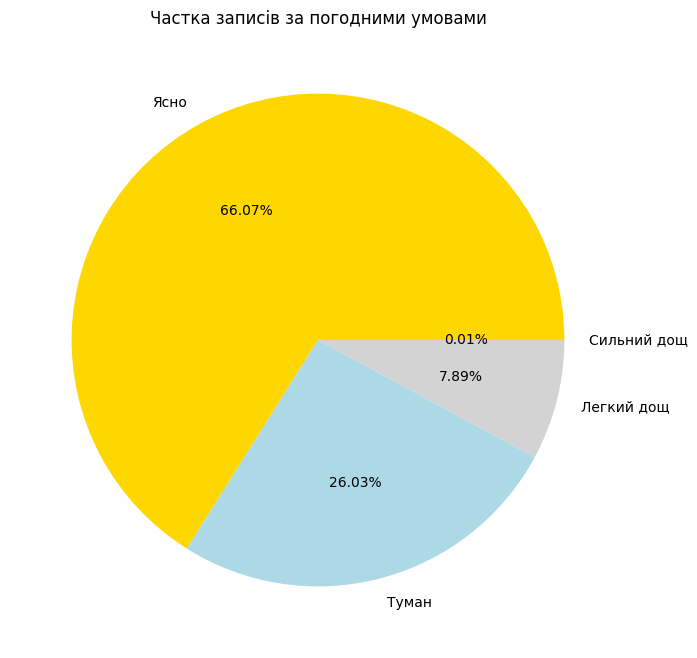

**Відповіді на питання :**

1.   *Яка погода переважає в датасеті?*

* У датасеті переважає ясна погода, на яку припадає 66,07% усіх спостережень. Туман становить 26,03%, а легкий дощ — лише 7,89%. Отже, приблизно дві третини всіх записів характеризуються сприятливими погодними умовами без дощу.

2.  *Чи є дні із сильним дощем? Яка їх частка?*


*   Спостереження із сильним дощем є, але їх частка надзвичайно мала — лише 0,01%. Раніше ми перевірили кількість таких записів і отримали лише 1 спостереження. Тому сильний дощ у цьому датасеті є винятковою погодною умовою і практично не впливає на загальний розподіл.


3.   *Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?*


* Можна припустити, що сприятливі погодні умови позитивно впливають на попит, оскільки за ясної погоди користуватися велосипедом комфортніше. Дощ, туман та інші несприятливі умови можуть знижувати бажання користувачів орендувати велосипеди. Проте ця кругова діаграма показує лише частоту погодних умов, а не безпосередньо їхній вплив на кількість оренд, тому для обґрунтованого висновку потрібно окремо порівняти середню кількість count для кожного типу weather.


## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [103]:
# Створюємо функцію для заміни числового коду погоди на назву
def weather_name(weather):
    if weather == 1:
        return 'Ясно'
    elif weather == 2:
        return 'Туман'
    elif weather == 3:
        return 'Легкий дощ'
    else:
        return 'Сильний дощ'


# Створюємо нову колонку з назвами погодних умов
df['weather_name'] = df['weather'].apply(weather_name)

In [104]:
# Перевіряємо унікальні значення погодних умов
df['weather_name'].unique()

array(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'], dtype=object)

In [105]:
# Рахуємо кількість записів для кожного типу погоди
df['weather_name'].value_counts()

,count
weather_name,
Ясно,7192
Туман,2834
Легкий дощ,859
Сильний дощ,1


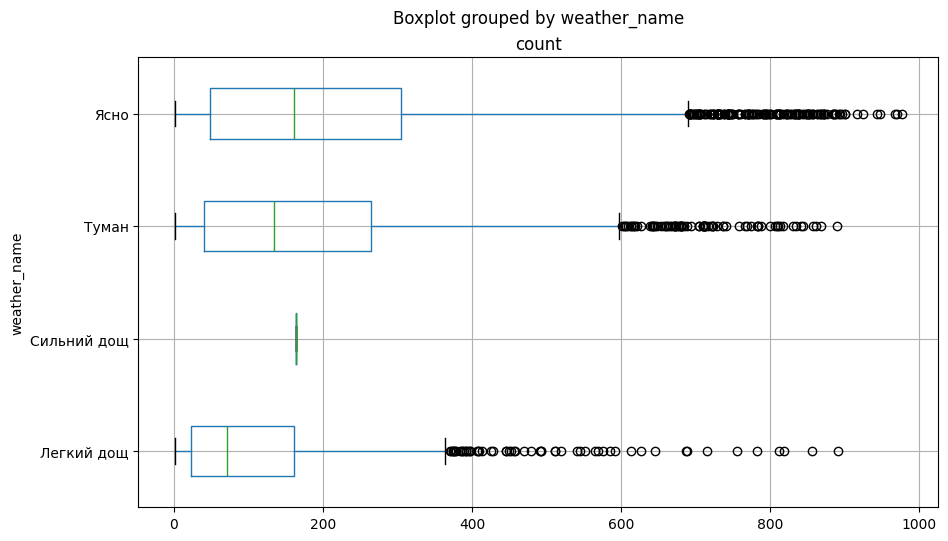

In [106]:
# Будуємо горизонтальний Box Plot кількості оренд за типами погоди
df.boxplot(
    column='count',        # Аналізуємо кількість оренд
    by='weather_name',     # Групуємо за погодними умовами
    vert=False,            # Горизонтальна орієнтація
    figsize=(10, 6),       # Розмір графіка
    grid=True              # Додаємо сітку
);

**Відповіді на питання :**

1.   *При якій погоді найбільший розкид у кількості оренди?*

* Найбільший розкид спостерігається за ясної погоди: коробка є найширшою, а значення разом із викидами простягаються майже до 1000 оренд. За туману розкид також значний, але дещо менший. При легкому дощі основна частина значень зосереджена нижче, хоча присутні окремі дуже високі значення. Для сильного дощу оцінювати розкид некоректно, оскільки в датасеті є лише одне спостереження.

2.  *Чи є викиди (outliers) в даних? При якій погоді?*


*   Так, викиди добре помітні для ясної погоди, туману та легкого дощу — це окремі точки, що знаходяться праворуч за межами «вусів» Box Plot. Найбільша кількість високих викидів спостерігається при ясній погоді, де окремі значення наближаються до 1000 оренд. При легкому дощі викидів також багато, хоча типові значення оренди нижчі. Для сильного дощу викиди визначити неможливо через наявність лише одного запису.


3.   *При якій погоді медіанне значення оренди найвище?*


* Найвище медіанне значення оренди спостерігається за ясної погоди — зелена лінія медіани розташована правіше, ніж для туману та легкого дощу. Туман має трохи нижчу медіану, а найнижча медіана серед категорій із достатньою кількістю даних — при легкому дощі. Це свідчить, що за сприятливіших погодних умов типова кількість оренд у середньому вища. Значення для сильного дощу не варто порівнювати з іншими категоріями, оскільки воно базується лише на одному спостереженні.


## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

In [107]:
# Створюємо функцію, яка задає колір для кожного сезону
def season_color(season):
    if season == 'Winter':
        return 'steelblue'
    elif season == 'Summer':
        return 'goldenrod'
    elif season == 'Monsoon':
        return 'seagreen'
    else:
        return 'plum'



In [108]:
# Створюємо колонку з кольором для кожного запису
df['season_color'] = df['weather_season_india'].apply(season_color)

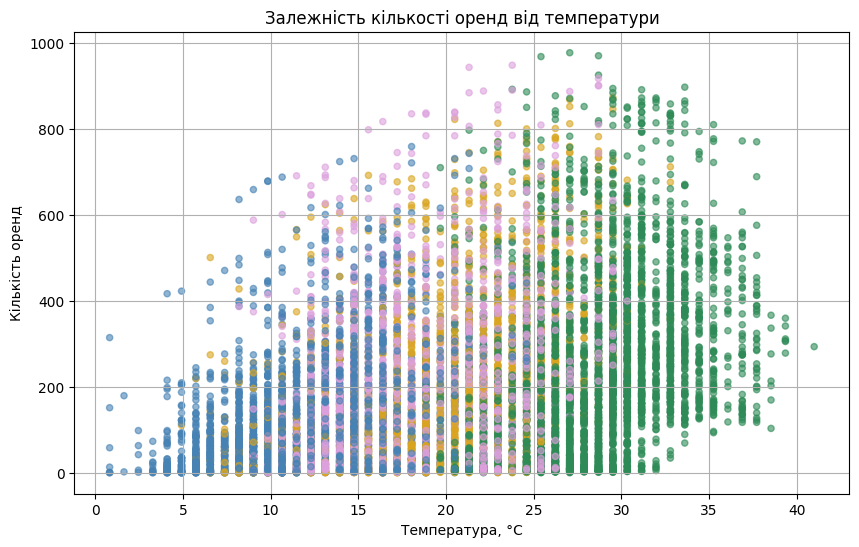

In [109]:
# Будуємо діаграму розсіювання залежності кількості оренд від температури
df.plot.scatter(
    x='temp',                     # Температура по осі X
    y='count',                    # Кількість оренд по осі Y
    c=df['season_color'],         # Розфарбовуємо точки за сезонами
    alpha=0.6,                    # Додаємо напівпрозорість
    figsize=(10, 6),              # Розмір графіка
    title='Залежність кількості оренд від температури',
    xlabel='Температура, °C',
    ylabel='Кількість оренд',
    grid=True
);

**Відповіді на питання :**

1.   *Чи є зв'язок між температурою та кількістю оренди? Який?*

* Так, між температурою та кількістю оренд простежується позитивний зв’язок: зі зростанням температури загальна кількість оренд у середньому збільшується. Особливо це помітно при переході від низьких температур до приблизно 25–30 °C, де з’являється найбільше спостережень із високою кількістю оренд. Водночас точки мають значний розкид, тому залежність не є строго лінійною — за однакової температури кількість оренд може суттєво відрізнятися. Це означає, що температура є важливим, але не єдиним фактором, який впливає на попит.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [110]:
# Розраховуємо середню кількість оренд
# для випадкових та зареєстрованих користувачів за днями тижня
weekday_users = df.groupby('weekday')[['casual', 'registered']].mean().round(2)

# Встановлюємо правильний порядок днів тижня
weekday_users = weekday_users.loc[
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
     'Friday', 'Saturday', 'Sunday']
]

# Переглядаємо результат
weekday_users

,casual,registered
weekday,,
Monday,29.84,160.55
Tuesday,22.98,166.74
Wednesday,22.52,165.89
Thursday,24.01,173.29
Friday,31.00,166.84
Saturday,63.62,133.04
Sunday,57.05,123.79


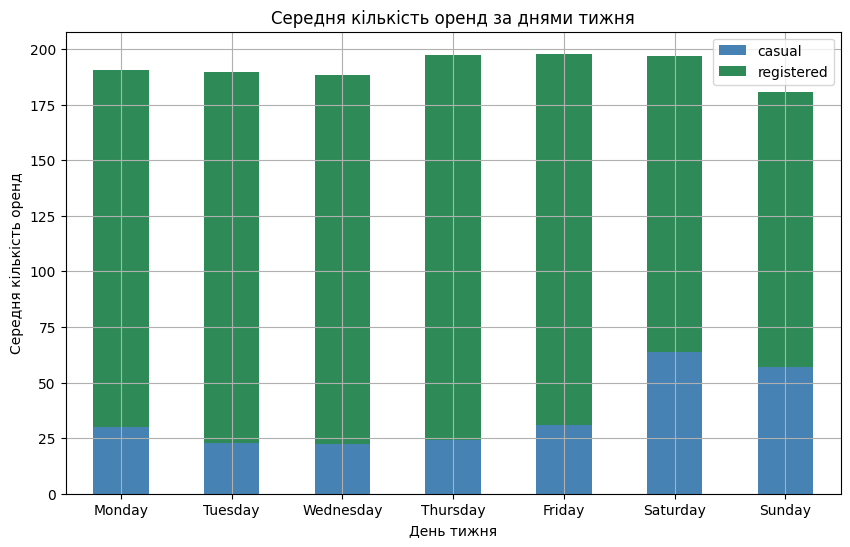

In [111]:
# Будуємо стовпчасту діаграму з накопиченням
# для порівняння типів користувачів за днями тижня
weekday_users.plot.bar(
    stacked=True,                         # Стовпці з накопиченням
    figsize=(10, 6),                      # Розмір графіка
    color=['steelblue', 'seagreen'],      # Кольори типів користувачів
    title='Середня кількість оренд за днями тижня',
    xlabel='День тижня',
    ylabel='Середня кількість оренд',
    grid=True,
    rot=0                                 # Підписи днів горизонтально
);

**Відповіді на питання :**

1.   *В які дні тижня більше оренд від зареєстрованих користувачів?*

* Зареєстровані користувачі переважають над випадковими в усі дні тижня, але найбільше це помітно у будні. Найвища середня кількість оренд зареєстрованими користувачами спостерігається приблизно у четвер, також високі значення мають вівторок, середа та п’ятниця. У суботу та неділю кількість оренд від зареєстрованих користувачів зменшується, водночас частка casual помітно зростає.

2.  *Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?*


*   Можна припустити, що зареєстровані користувачі частіше використовують велосипеди у будні для регулярних поїздок — наприклад, на роботу або навчання, тому їхня активність у цей період вища. У вихідні потреба в таких регулярних поїздках зменшується, через що кількість оренд registered падає. Натомість кількість оренд casual у суботу та неділю суттєво зростає, що може бути пов’язано з відпочинком, прогулянками та дозвіллям. Таким чином, графік показує різну модель використання велосипедів зареєстрованими та випадковими користувачами протягом тижня.